In [1]:
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
!pip install spark --quiet
print("Pyspark Installed Successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.7/351.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.5 MB/s eta 0:00:00
Pyspark Installed Successfully


In [2]:
df = pd.read_csv('/content/drive/MyDrive/15 days intern dataset/student_performance.csv')
print("===== Dataset Uploaded Successfully =====")
print()

df

===== Dataset Uploaded Successfully =====



,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023


In [3]:
print("No of rows:", len(df))
print("NO of columns:", len(df.columns))
print()

print("=== First 5 Rows ===")
print()
print(df.head())

No of rows: 30
NO of columns: 13

=== First 5 Rows ===

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1     

In [4]:
# Create new connection
conn = sqlite3.connect('student.db')

# Store dataframe
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

# SQL Query
query = "SELECT name, age FROM students where age>20"

result = pd.read_sql(query, conn)

print(result)

# Close connection
conn.close()

            name  age
0    Kiran Kumar   21
1     Suresh Rao   21
2   Manoj Pandey   21
3   Sanjay Dubey   21
4  Gaurav Shukla   21


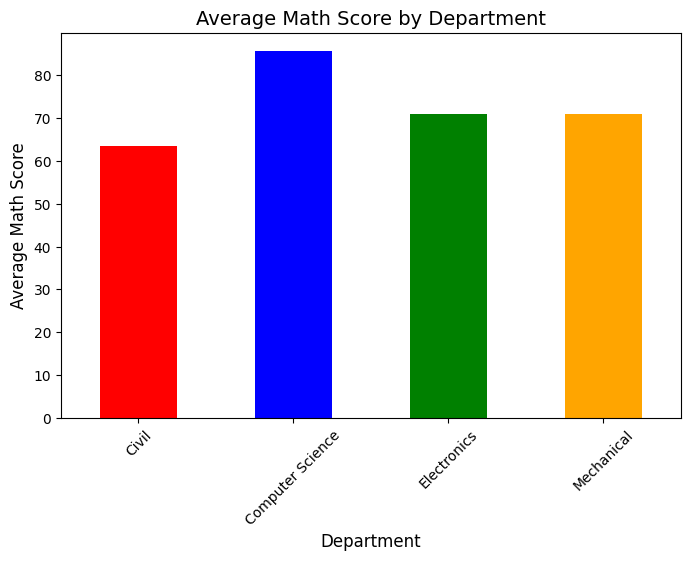

In [5]:
avg_math = df.groupby('department')['math_score'].mean()

plt.figure(figsize=(8,5))

avg_math.plot(
    kind='bar',
    color=['red', 'blue', 'green', 'orange']
)

plt.title("Average Math Score by Department", fontsize=14)
plt.xlabel("Department", fontsize=12)
plt.ylabel("Average Math Score", fontsize=12)

plt.xticks(rotation=45)

plt.show()

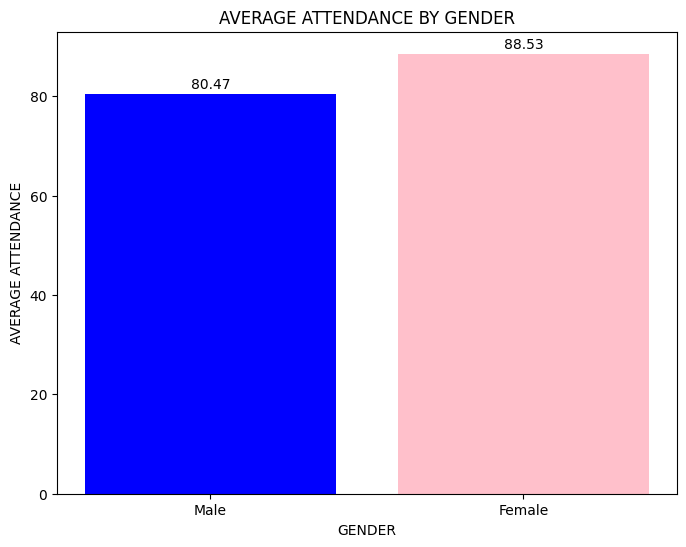

In [6]:
# Calculate average attendance by gender
data = df.groupby('gender')['attendance_percentage'].mean().reset_index()
data.rename(columns={'attendance_percentage': 'avg_attendance'}, inplace=True)

data = data.set_index('gender').reindex(['Male', 'Female']).reset_index()

fig, ax = plt.subplots(figsize=(8,6))

plt.title("AVERAGE ATTENDANCE BY GENDER")
plt.xlabel("GENDER")
plt.ylabel("AVERAGE ATTENDANCE")

bars = plt.bar(
    data['gender'],
    data['avg_attendance'],
    color=['blue', 'pink']
)

# Add attendance values on bars
for bar in bars:
    attendance_value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        attendance_value + 0.5,
        round(attendance_value, 2),
        ha='center',
        va='bottom'
    )

plt.show()

In [7]:
import numpy as np

# Create missing values manually
df.loc[2, 'math_score'] = np.nan
df.loc[5, 'age'] = np.nan
df.loc[8, 'department'] = np.nan
df.loc[11, 'gender'] = np.nan

print("=== Missing Values ====")
print(df.isnull().sum())
print()
print("---- Total Missing Values ---")
print("Total:",df.isnull().sum().sum())

=== Missing Values ====
student_id               0
name                     0
age                      1
gender                   1
department               1
semester                 0
math_score               1
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64

---- Total Missing Values ---
Total: 4


In [8]:
print("---- Number Of Duplicate values ----")
print("Duplicates:",df.duplicated().sum())

print()

print("----Data Types ---")
print(df.dtypes)

---- Number Of Duplicate values ----
Duplicates: 0

----Data Types ---
student_id                 int64
name                      object
age                      float64
gender                    object
department                object
semester                   int64
math_score               float64
science_score              int64
english_score              int64
programming_score          int64
attendance_percentage      int64
city                      object
admission_year             int64
dtype: object


In [9]:
print("==== Handle Missing Values ====")
print()
df['math_score'].fillna(df['math_score'].mean(), inplace=True)
df['age'].fillna(df['age'].mean(), inplace=True)
df['department'].fillna(df['department'].mode()[0], inplace=True)
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

print("Total Missing Values:", df.isnull().sum().sum())

==== Handle Missing Values ====

Total Missing Values: 0


In [10]:
print("=== Fetch With API Using OpenWeather ===")
API_KEY = '576cc3a978403901abae8e5c256f1e20'
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'
CITIES = ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Kolkata','Pune','Jaipur']
print("API Configured:",len(CITIES))
print(CITIES)

=== Fetch With API Using OpenWeather ===
API Configured: 8
['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']


In [11]:
import requests
def fetch_weather(city, api_key):
  params={
      'q':city,
      'appid':api_key,
      'units':'metric'
  }

  try:
    response=requests.get(BASE_URL,params=params,timeout=10)

    if response.status_code==200:
      data=response.json()

      return{
          'city': city,
          'temperature':round(data['main']['temp'],1),
          'description':data['weather'][0]['description'],
          'humidity':data['main']['humidity'],
          'wind_speed':data['wind']['speed'],
          'pressure': data['main']['pressure'],
          'condition':data['weather'][0]['description'].title(),
          'visibility':data.get('visibility',0)//1000
      }
    else:
      print(f'Error {response.status_code} for {city}: {response.json().get("message","Unknown Error")}')
      return None
  except requests.exceptions.ConnectionError:
    print('Connection Error')
    return None
  except requests.exceptions.Timeout:
    print('Request Timeout')

In [12]:
Chennai_city = fetch_weather(CITIES[3],API_KEY)
print("Fetching the API KEY !!!!!!")
print("")
if Chennai_city:
  print(Chennai_city)
else:
  print('Error fetching weather data')

Fetching the API KEY !!!!!!

{'city': 'Chennai', 'temperature': 33.0, 'description': 'overcast clouds', 'humidity': 70, 'wind_speed': 3.58, 'pressure': 1005, 'condition': 'Overcast Clouds', 'visibility': 10}


In [13]:
# FULL WORKING CODE #

import requests
import pandas as pd

weather_records = []

def fetch_weather(city, api_key):

    params = {
        'q': city,
        'appid': api_key,
        'units': 'metric'
    }

    try:

        response = requests.get(
            BASE_URL,
            params=params,
            timeout=10
        )

        if response.status_code == 200:

            data = response.json()

            return {
                'city': city,
                'temperature': round(data['main']['temp'], 1),
                'description': data['weather'][0]['description'],
                'humidity': data['main']['humidity'],
                'wind_speed': data['wind']['speed'],
                'pressure': data['main']['pressure'],
                'condition': data['weather'][0]['description'].title(),
                'visibility': data.get('visibility', 0) // 1000
            }

        else:

            print(
                f"Error {response.status_code} for {city}"
            )

            return None

    except requests.exceptions.ConnectionError:

        print("Connection Error")
        return None

    except requests.exceptions.Timeout:

        print("Request Timeout")
        return None


# Fetch all cities weather

for city in CITIES:

    result = fetch_weather(city, API_KEY)

    if result:

        weather_records.append(result)


# Convert into dataframe

weather_df = pd.DataFrame(weather_records)

print("Weather dataframe created\n")

print(weather_df.to_string(index=False))

print("\nShape:", weather_df.shape)

print()
print("="*150)

print("\nMissing Values:")
print(weather_df.isnull().sum())

print()
print("="*140)

print("\nData Types:")
print(weather_df.dtypes)

Weather dataframe created

     city  temperature     description  humidity  wind_speed  pressure       condition  visibility
   Mumbai         31.6      few clouds        72        6.25      1007      Few Clouds          10
    Delhi         40.8       clear sky        16        4.64       998       Clear Sky          10
Bangalore         25.2 overcast clouds        73       11.18      1010 Overcast Clouds          10
  Chennai         33.0 overcast clouds        70        3.58      1005 Overcast Clouds          10
Hyderabad         28.8      light rain        58        7.17      1005      Light Rain          10
  Kolkata         30.4   moderate rain        73        6.65      1003   Moderate Rain           2
     Pune         31.3 overcast clouds        38        6.01      1009 Overcast Clouds          10
   Jaipur         35.2   broken clouds        28        3.96      1002   Broken Clouds          10

Shape: (8, 8)


Missing Values:
city           0
temperature    0
description    

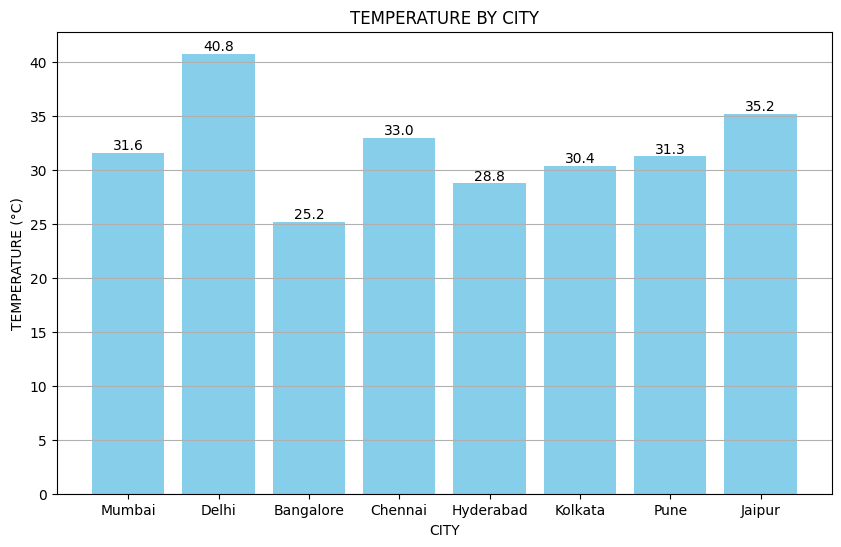

In [14]:
fig, ax = plt.subplots(figsize=(10,6))

bars = plt.bar(
    weather_df['city'],
    weather_df['temperature'],
    color='skyblue'
)

plt.title("TEMPERATURE BY CITY")
plt.xlabel("CITY")
plt.ylabel("TEMPERATURE (°C)")

# Add values on bars
for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.3,
        round(value,1),
        ha='center'
    )

plt.grid(axis='y')

plt.show()

In [15]:
# Create Spark Session

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("StudentPerformance") \
    .getOrCreate()

In [16]:
bronze_df = spark.read.csv(
    '/content/drive/MyDrive/15 days intern dataset/student_performance.csv',
    header=True,
    inferSchema=True
)

In [17]:
print("===== First Five Rows =====")
print()
bronze_df.show(5, truncate=False)

print()

print("===== Last Five Rows =====")
print()
last = bronze_df.tail(5)
spark.createDataFrame(last, bronze_df.schema).show(truncate=False)

===== First Five Rows =====

+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|student_id|name        |age|gender|department      |semester|math_score|science_score|english_score|programming_score|attendance_percentage|city     |admission_year|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|1001      |Aarav Sharma|19 |Male  |Computer Science|2       |85        |78           |72           |91               |92                   |Mumbai   |2023          |
|1002      |Priya Patel |20 |Female|Computer Science|2       |76        |82           |88           |79               |87                   |Ahmedabad|2023          |
|1003      |Rohit Verma |19 |Male  |Electronics     |2       |65        |74           |61           |55               |78               

In [19]:
!pip install groq pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 1.0 MB/s eta 0:00:00


In [20]:
import pandas as pd
import numpy as np
import os
import sqlite3
from groq import Groq
import re

In [21]:
import os
os.environ["GROQ_API_KEY"] = "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"
client = Groq(api_key=os.environ["GROQ_API_KEY"])
MODEL = "llama-3.1-8b-instant"
print("Using Model : ",MODEL)

Using Model :  llama-3.1-8b-instant


In [22]:
import io
df = pd.read_csv("/content/drive/MyDrive/15 days intern dataset/student_performance.csv")
print("=== Data Loaded Successfully ===")
print("-"*40)
df.head(5)


=== Data Loaded Successfully ===
----------------------------------------


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("All Libraries Imported Sucessfully !!!!")

All Libraries Imported Sucessfully !!!!


In [24]:
print("=== GENDER ENCODING ===")
df_ml = df.copy()
le_gender = LabelEncoder()
df_ml['gender'] = le_gender.fit_transform(df_ml['gender'])
print(f"Gender encoding : {dict(zip(le_gender.classes_,le_gender.transform(le_gender.classes_)))}")

=== GENDER ENCODING ===
Gender encoding : {'Female': np.int64(0), 'Male': np.int64(1)}


In [25]:
print("=== DEPARTMENT ENCODING ===")
le_dept = LabelEncoder()
df_ml['department'] = le_dept.fit_transform(df_ml['department'])
print(f"Department Encoding : {dict(zip(le_dept.classes_,le_dept.transform(le_dept.classes_)))}")

=== DEPARTMENT ENCODING ===
Department Encoding : {'Civil': np.int64(0), 'Computer Science': np.int64(1), 'Electronics': np.int64(2), 'Mechanical': np.int64(3)}


In [26]:
print("=== SEMESTER ENCODING ===")
le_sem = LabelEncoder()
df_ml['semester'] = le_sem.fit_transform(df_ml['semester'])
print(f"Semester Encoding : {dict(zip(le_sem.classes_,le_sem.transform(le_sem.classes_)))}")

=== SEMESTER ENCODING ===
Semester Encoding : {np.int64(2): np.int64(0)}


In [27]:
feature_col = [
    'math_score',
    'science_score',
    'attendance_percentage',
    'gender',
    'department'
]
x = df_ml[feature_col]
y = df_ml['programming_score']
print("Feature Matrix X shape : ",x.shape)
print("Target Vector Y shape : ",y.shape)
print(f"Target Range from  {y.min()} to {y.max()} mean : {y.mean():.1f}")

Feature Matrix X shape :  (30, 5)
Target Vector Y shape :  (30,)
Target Range from  38 to 97 mean : 67.6


In [28]:
X_train , X_test ,Y_train , Y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)
print(f"Total Students : {len(x)}")
print(f"Training Students : {len(X_train)} : ({len(X_train)/len(x)*100:.0f}) %")
print(f"Testing Students : {len(X_test)} ({len(X_test)/len(x)*100:.0f})")
print(f"Traininf target Range {Y_train.min()} to {Y_train.max()} mean : {Y_train.mean():.1f}")
print(f"Testing target Range {Y_test.min()} to {Y_test.max()} mean : {Y_test.mean():.1f}")

Total Students : 30
Training Students : 24 : (80) %
Testing Students : 6 (20)
Traininf target Range 38 to 96 mean : 68.0
Testing target Range 39 to 97 mean : 65.8


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
print("=== Features Scaled Sucessfully ===")
X_test_scaled =  scaler.transform(X_test)
print(f"Training feature mean (should be 0 ) : {X_train_scaled.mean():.4f}")
print("Traing feature Std (should be -1 ) : ",X_train_scaled.std())

=== Features Scaled Sucessfully ===
Training feature mean (should be 0 ) : 0.0000
Traing feature Std (should be -1 ) :  1.0


In [30]:

lr_model = LinearRegression()
lr_model.fit(X_train_scaled,Y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(Y_test,lr_pred)
lr_mse = np.sqrt(mean_squared_error(Y_test,lr_pred))
lr_r2 = r2_score(Y_test,lr_pred)
lr_rmse = np.sqrt(lr_mse)

print("=== MODEL IN LINEAR REGRESSION AND ML PREDICTION ===")
print(f"MAE : {lr_mae:.2f}")
print(f"MSE : {lr_mse:.2f}")
print(f"R2 : {lr_r2:.4f}")
print(f"RMSE : {lr_rmse:.2f}")
results = pd.DataFrame({
    "Actual_Score": Y_test.values,
    "Predicted_Score": lr_pred
})

=== MODEL IN LINEAR REGRESSION AND ML PREDICTION ===
MAE : 9.84
MSE : 11.88
R2 : 0.7164
RMSE : 3.45


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, Y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Metrics
lr_mae = mean_absolute_error(Y_test, lr_pred)
lr_mse = mean_squared_error(Y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(Y_test, lr_pred)

print("=== LINEAR REGRESSION MODEL PERFORMANCE ===")
print(f"MAE  : {lr_mae:.2f}")
print(f"MSE  : {lr_mse:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.4f}")

# Create results DataFrame
results = pd.DataFrame({
    "Actual_Score": Y_test.values,
    "Predicted_Score": lr_pred
})

print("\n=== PREDICTIONS WITH NATURAL LANGUAGE ===")

for i, row in results.head(10).iterrows():   # change 10 to len(results) for all rows
    print(
        f"Student {i+1}: "
        f"Predicted Score = {row['Predicted_Score']:.1f}, "
        f"Actual Score = {row['Actual_Score']:.1f}. "
        f"The model predicts that this student is expected to score "
        f"approximately {row['Predicted_Score']:.1f} marks."
    )

=== LINEAR REGRESSION MODEL PERFORMANCE ===
MAE  : 9.84
MSE  : 141.09
RMSE : 11.88
R²   : 0.7164

=== PREDICTIONS WITH NATURAL LANGUAGE ===
Student 1: Predicted Score = 44.0, Actual Score = 39.0. The model predicts that this student is expected to score approximately 44.0 marks.
Student 2: Predicted Score = 85.4, Actual Score = 69.0. The model predicts that this student is expected to score approximately 85.4 marks.
Student 3: Predicted Score = 73.1, Actual Score = 53.0. The model predicts that this student is expected to score approximately 73.1 marks.
Student 4: Predicted Score = 94.5, Actual Score = 92.0. The model predicts that this student is expected to score approximately 94.5 marks.
Student 5: Predicted Score = 56.3, Actual Score = 45.0. The model predicts that this student is expected to score approximately 56.3 marks.
Student 6: Predicted Score = 100.7, Actual Score = 97.0. The model predicts that this student is expected to score approximately 100.7 marks.
